## Library imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sb
import os

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("diabetes_unclean_dsn.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1025 non-null   int64  
 1   No_Pation  1025 non-null   int64  
 2   Gender     1025 non-null   str    
 3   AGE        1024 non-null   float64
 4   Urea       1024 non-null   float64
 5   Cr         1023 non-null   float64
 6   HbA1c      1022 non-null   float64
 7   Chol       1023 non-null   float64
 8   TG         1023 non-null   float64
 9   HDL        1024 non-null   float64
 10  LDL        1023 non-null   float64
 11  VLDL       1024 non-null   float64
 12  BMI        1025 non-null   float64
 13  CLASS      1025 non-null   str    
dtypes: float64(10), int64(2), str(2)
memory usage: 114.3 KB


In [6]:
df.duplicated().sum()

np.int64(16)

In [7]:
# remove the duplicates
dup = df.duplicated(keep = 'first')
df = df[~dup]
len(df)

1009

In [8]:
#Check for missing values

df.isnull().sum()

ID           0
No_Pation    0
Gender       0
AGE          1
Urea         1
Cr           2
HbA1c        3
Chol         2
TG           2
HDL          1
LDL          2
VLDL         1
BMI          0
CLASS        0
dtype: int64



### Why We Fill Missing Values
Handling missing values is a critical step in data preprocessing. Missing values can cause issues with machine learning algorithms, which often require complete datasets to function correctly. By filling in missing values, we ensure that our model can be trained without errors and that it makes the best use of the available data.

### Why We Used the Median for Numerical Columns
For numerical columns, we chose to fill missing values with the median. The median is a robust measure of central tendency that is less affected by outliers compared to the mean. This makes it a good choice for imputation, especially in datasets where the distribution of the data may be skewed or contain outliers. By using the median, we minimize the risk of distorting the distribution of the data.

### Other Strategies for Handling Missing Values
There are several other strategies you can explore for handling missing values, including:

1. **Mean Imputation**: Replace missing values with the mean of the column. This is straightforward but can be influenced by outliers.
   
2. **Mode Imputation**: For categorical variables, replace missing values with the most frequent category (mode). This preserves the most common value in the dataset.

3. **Forward/Backward Fill**: For time-series data, you can use the previous (forward fill) or next (backward fill) value to fill missing data points. This maintains the temporal order of the data.

4. **Interpolation**: For numerical data, interpolate missing values using linear or polynomial methods. This can be useful for time-series data where you want to maintain the trend.

5. **Predictive Modeling**: Use a machine learning model to predict and fill missing values based on other available features. This can be more accurate but requires building and validating a separate model for imputation.

6. **Deletion**: In some cases, you might choose to remove rows or columns with missing values. This is only advisable if the amount of missing data is small and won't significantly impact the analysis or model performance.

Choosing the right strategy depends on the specific characteristics of your dataset and the nature of the missing data. It's often useful to try different approaches and evaluate their impact on model performance.

In [9]:
# Drop missing values

df.dropna(inplace = True)

In [10]:
df.shape

(994, 14)

In [11]:
df.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='str')

In [17]:
# Check the Uniqueness of the categorical features

for col in df.select_dtypes("object").columns:
    print(f"{col} has {df[col].nunique()} unique values")
    print(f"Here is first 10: {df[col].unique()[:10]}")
    print()

Gender has 4 unique values
Here is first 10: <ArrowStringArray>
['F', 'M', 'm', 'f']
Length: 4, dtype: str

CLASS has 7 unique values
Here is first 10: <ArrowStringArray>
['N', 'n', 'N ', 'P', 'Y', 'y', 'Y ']
Length: 7, dtype: str



In [19]:
# correct inconsistence error in inputs

df.CLASS = df.CLASS.replace(['N ', 'Y ', 'n', 'y'],['N', 'Y', 'N', 'Y'])

df.Gender = df.Gender.replace(['m', 'f'],['M', 'F'])

In [20]:
df.CLASS.unique()

<ArrowStringArray>
['N', 'P', 'Y']
Length: 3, dtype: str

In [21]:
df.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,994.000000,9.940000e+02,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000
mean,341.635815,2.723022e+05,53.605634,5.129520,68.742455,8.286378,4.859678,2.343471,1.206187,2.610151,1.859054,29.598612
std,240.657144,3.390910e+06,8.758101,2.948246,60.087902,2.542578,1.299625,1.399343,0.662212,1.116133,3.674106,4.963877
min,1.000000,1.230000e+02,25.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.000000,2.406225e+04,51.000000,3.670000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,303.500000,3.439250e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,551.750000,4.538175e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


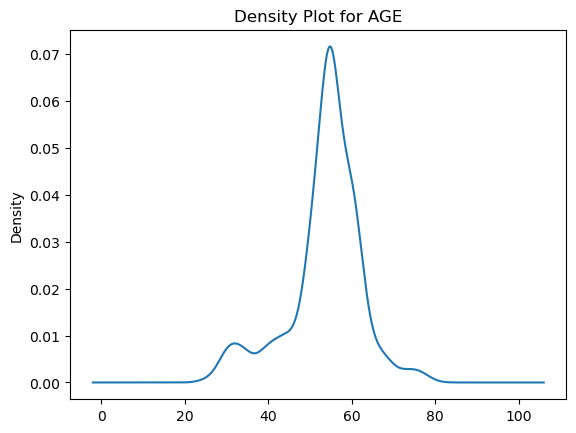

In [14]:
df['AGE'].plot(kind='density')
plt.title("Density Plot for AGE");

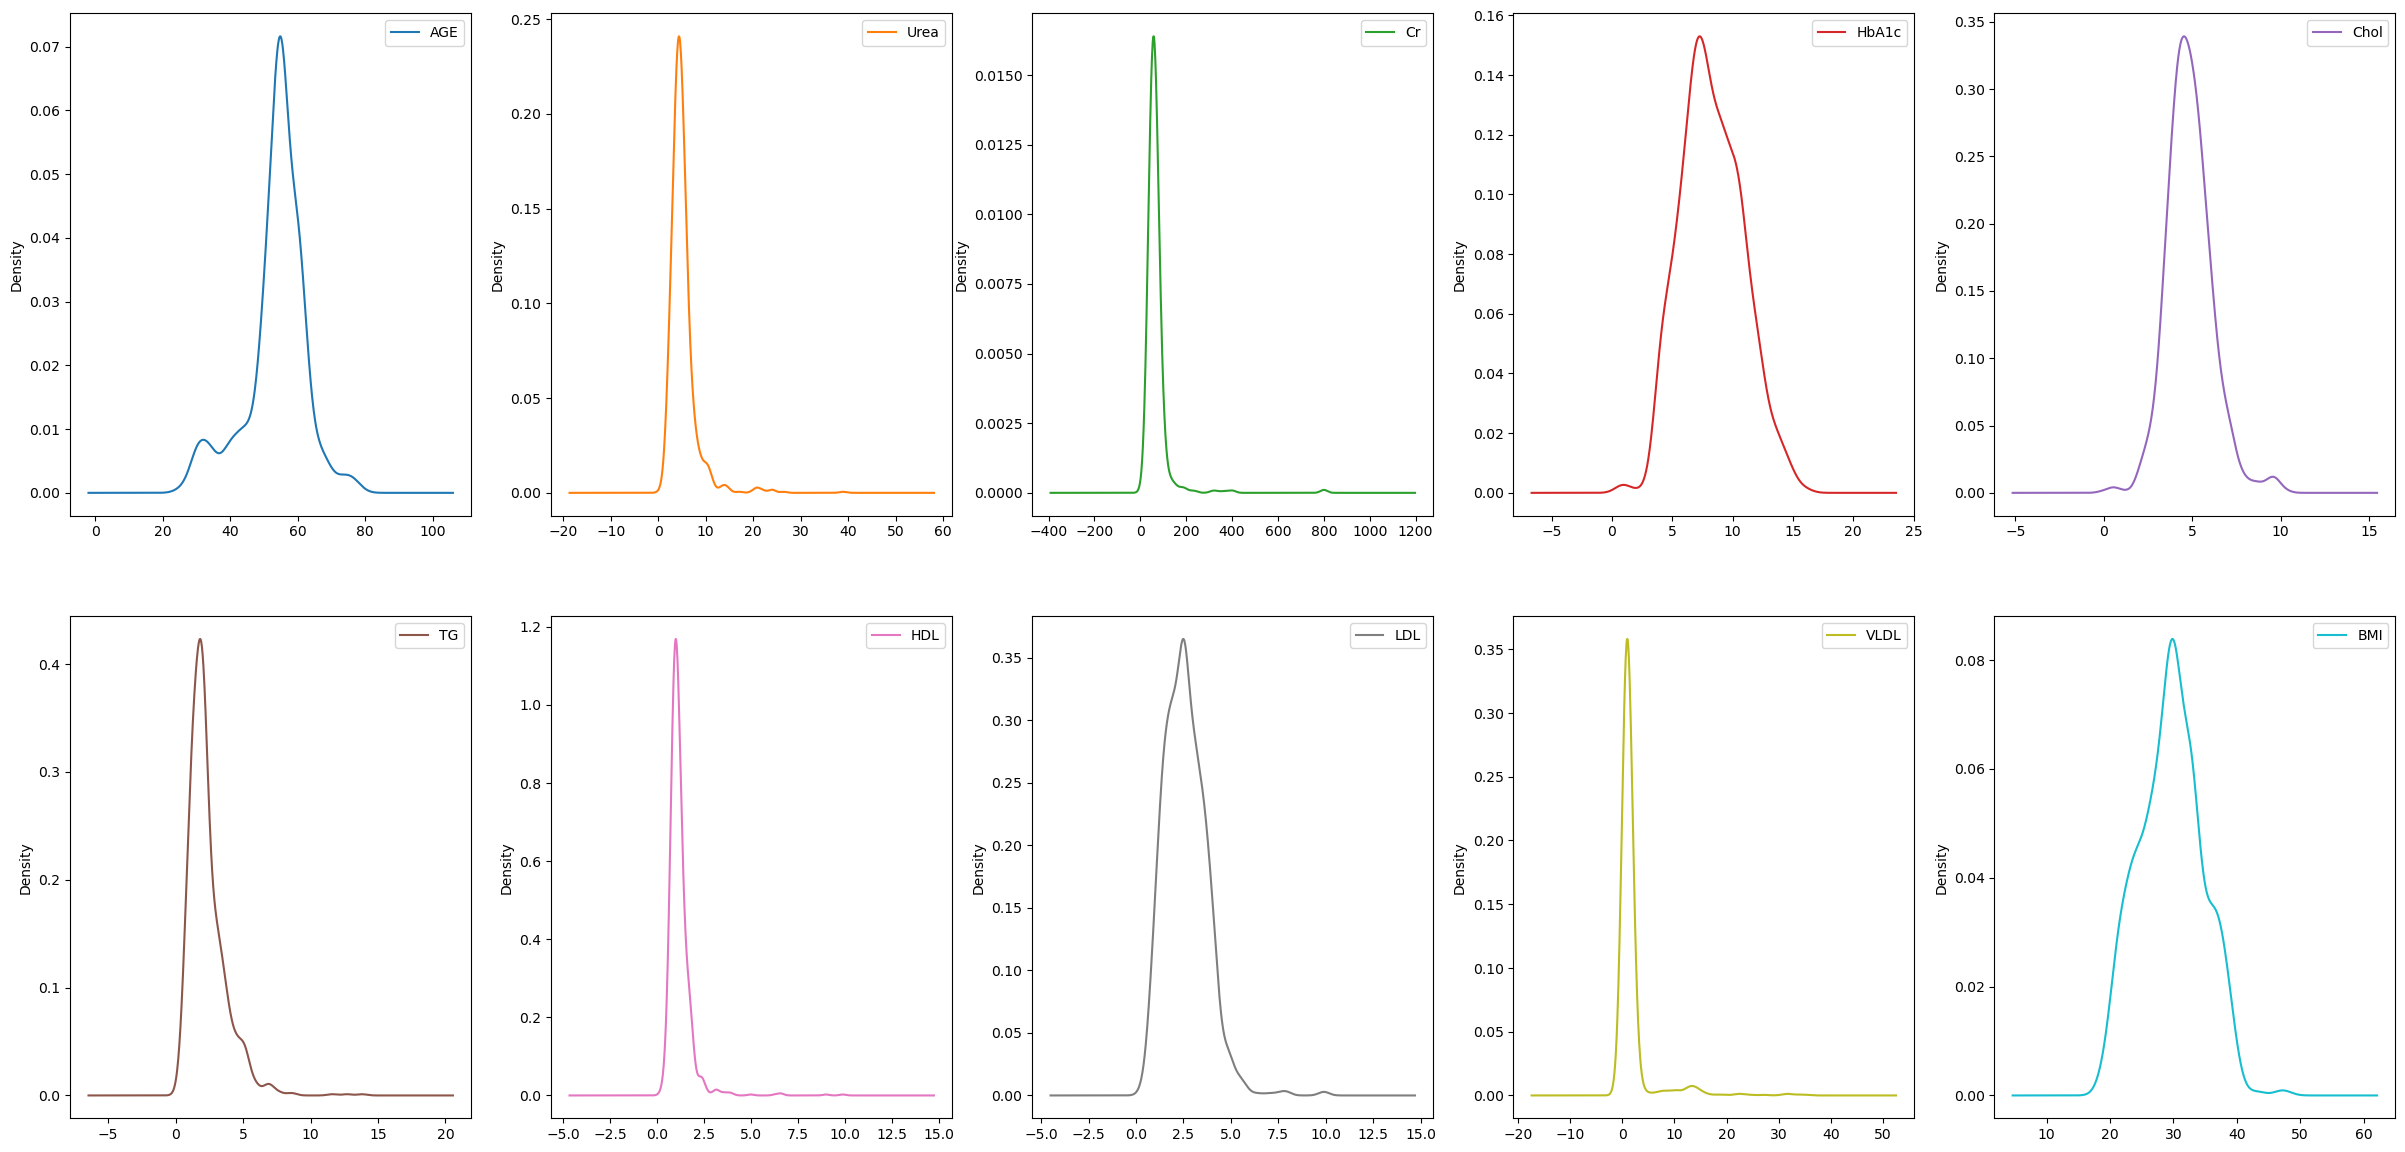

In [15]:
df_num = df[['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']]

df_num.plot(kind='density', subplots=True, layout= (4,5), sharex=False)
plt.gcf().set_size_inches(30,30)
plt.show()

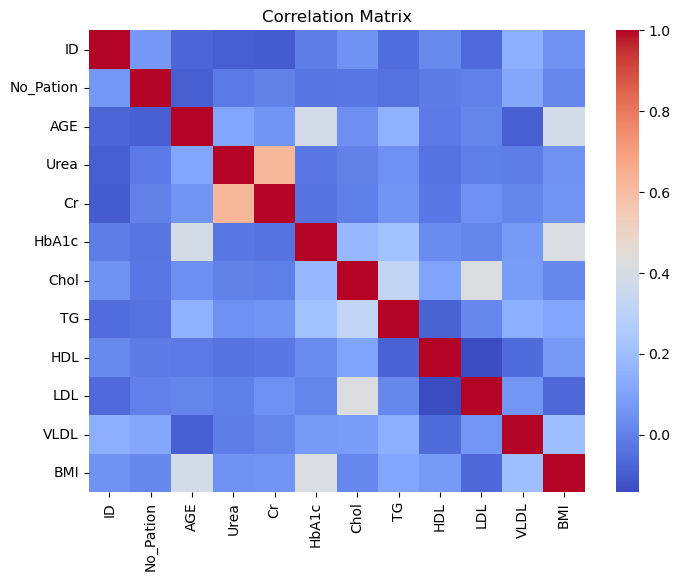

In [16]:
correlation = df.select_dtypes("number").corr()

plt.figure(figsize=(8, 6))
sb.heatmap(correlation, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


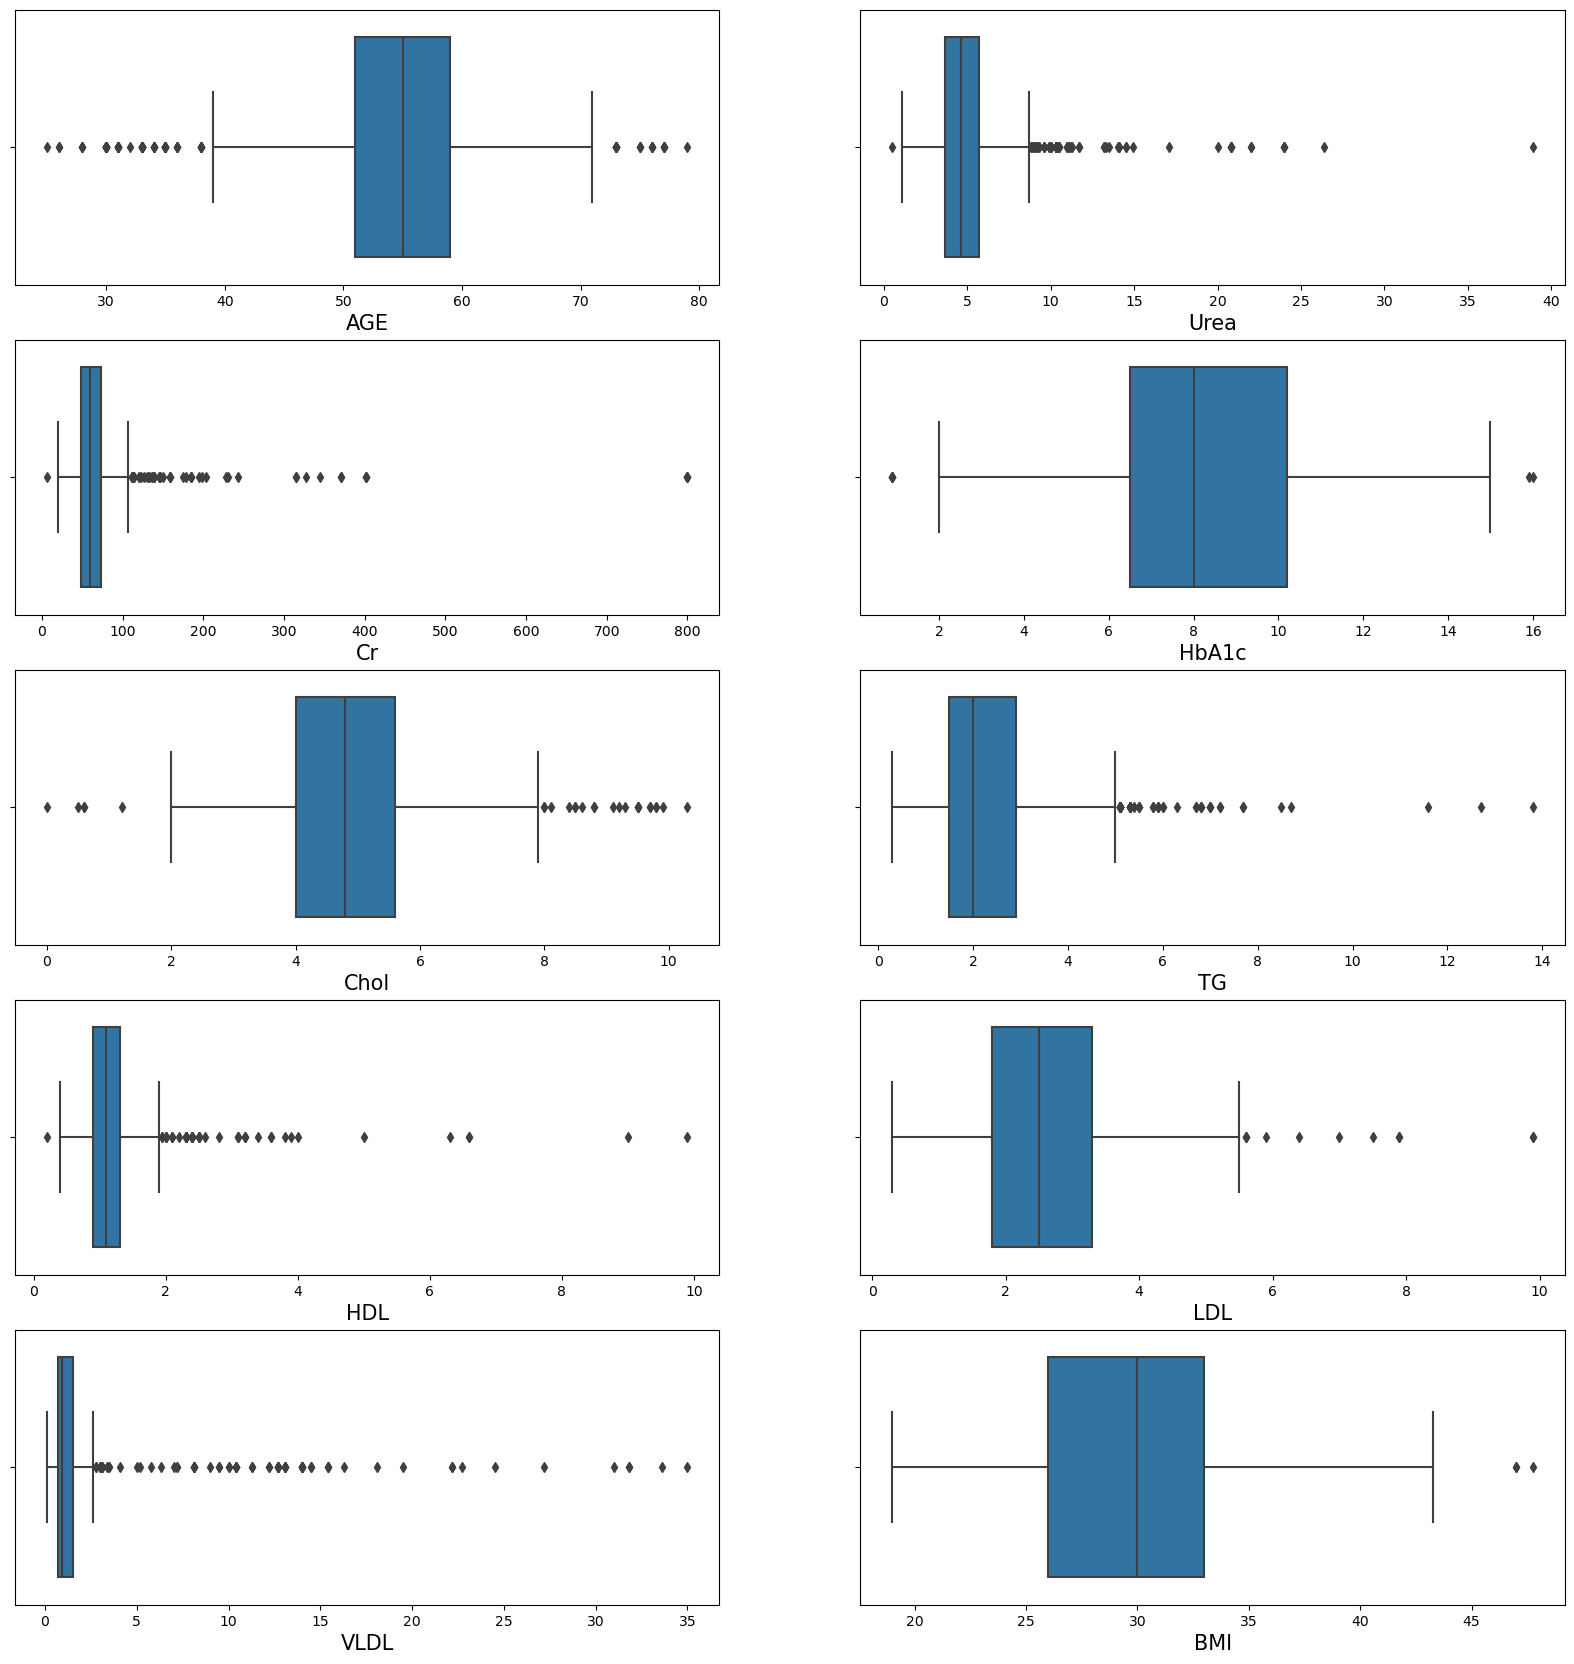

In [17]:
# Checking for outliers

df_num = df[['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']]

plt.figure(figsize = (20, 25))
for i in range (len(df_num.columns)):
    plt.subplot(6, 2, i+1)
    sb.boxplot(x = df_num.iloc[:, i])
    plt.xlabel(df_num.columns[i], size = 15)

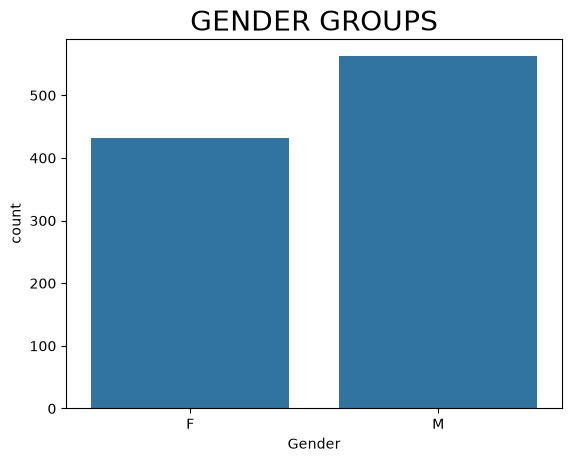

In [22]:
# Univariate plot

sb.countplot(x='Gender', data=df)
plt.title('GENDER GROUPS', fontsize = 20)
plt.show()

In [19]:
df['Gender'].value_counts(normalize = True)

Gender
M    0.565392
F    0.434608
Name: proportion, dtype: float64

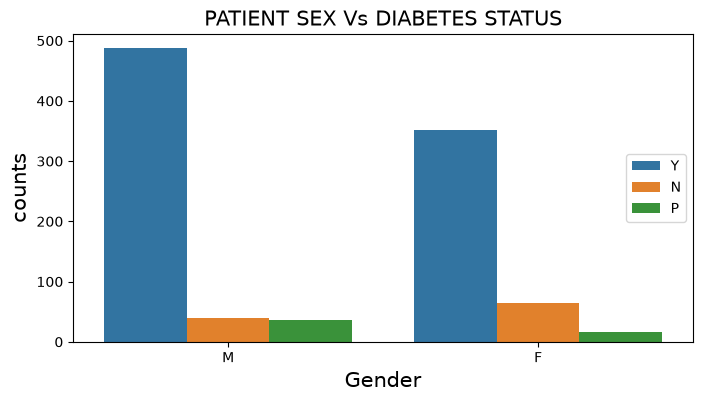

In [23]:
# Bi-variate and multi-variate plot

dfSub = pd.DataFrame(df, columns = ['Gender','CLASS'])
dfSub1 = pd.DataFrame(dfSub.groupby(['Gender','CLASS'
                                    ]).size().sort_values(ascending = False).rename('counts').reset_index())
plt.figure(figsize = (8,4))
plt.xlabel('Gender', fontsize = 15)
plt.ylabel("counts", fontsize = 15)
ax = sb.barplot(x = 'Gender', y ='counts', hue = 'CLASS', data = dfSub1)
ax.set_xticklabels(ax.get_xticklabels())
plt.legend(loc = 'right')
plt.title('PATIENT SEX Vs DIABETES STATUS', fontsize = 15)
plt.show();

In [24]:
df['CLASS'].unique()

<ArrowStringArray>
['N', 'P', 'Y']
Length: 3, dtype: str

In [25]:
# Replace the 'CLASS' with numeric

df.CLASS = df.CLASS.replace({"N": 0, "Y": 1, "P": 2})

In [26]:
print(df.ID.nunique())
print(df.No_Pation.nunique())

799
953


In [27]:
del df['ID']
del df['No_Pation']

In [28]:
from sklearn.feature_extraction import DictVectorizer

# Encoding the data via Dictvectorizer
dv = DictVectorizer(sparse = False)

dict = df.to_dict(orient='records')
df = dv.fit_transform(dict)

In [30]:
df = pd.DataFrame(df, columns=dv.get_feature_names_out())
df.head()

,AGE,BMI,CLASS,Chol,Cr,Gender=F,Gender=M,HDL,HbA1c,LDL,TG,Urea,VLDL
0,50.0,24.0,0.0,4.2,46.0,1.0,0.0,2.4,4.9,1.4,0.9,4.7,0.5
1,26.0,23.0,0.0,3.7,62.0,0.0,1.0,1.1,4.9,2.1,1.4,4.5,0.6
2,50.0,24.0,0.0,4.2,46.0,1.0,0.0,2.4,4.9,1.4,0.9,4.7,0.5
3,50.0,24.0,0.0,4.2,46.0,1.0,0.0,2.4,4.9,1.4,0.9,4.7,0.5
4,33.0,21.0,0.0,4.9,46.0,0.0,1.0,0.8,4.9,2.0,1.0,7.1,0.4


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction import DictVectorizer

# load raw data
df = pd.read_csv("diabetes_unclean_dsn.csv")
df.head()

# remove the duplicates
dup = df.duplicated(keep = 'first')
df = df[~dup]

# Drop missing values
df.dropna(inplace = True)

# correct inconsistence error in inputs in CLASS and Gender columns
df.CLASS = df.CLASS.replace(['N ', 'Y ', 'n', 'y'],['N', 'Y', 'N', 'Y'])
df.Gender = df.Gender.replace(['m', 'f'],['M', 'F'])

# Replace the 'CLASS' with numeric
df.CLASS = df.CLASS.replace({"N": 0, "Y": 1, "P": 2}).astype(int)

# Delete columns not need for model traininig
del df['ID']
del df['No_Pation']

# Seperate the data into dependent and independent variable
y = df['CLASS']
X = df.drop("CLASS", axis=1)

# Columns to scale
columns_to_scale = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

# Initialize RobustScaler
scaler = RobustScaler()

# Split the data to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply scaler to specified columns
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# Encoding the data via Dictvectorizer
dv = DictVectorizer(sparse = False)

dict_train = X_train.to_dict(orient='records')
dict_test = X_test.to_dict(orient='records')

X_train = dv.fit_transform(dict_train)
X_test = dv.transform(dict_test)

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9396984924623115


In [61]:
import joblib

# Save artifacts
joblib.dump(dv, "dv.bin")
joblib.dump(scaler, "scaler.bin")
joblib.dump(model, "model.bin")

['model.bin']

In [38]:
import joblib

dv = joblib.load("dv.bin")
scaler = joblib.load("scaler.bin")
model = joblib.load("model.bin")